In [2]:
import pandas as pd
import numpy as np


import matplotlib as plt

import seaborn as sns

In [3]:
df = pd.read_csv("../data/cleaned_cars_2.csv")

In [4]:
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243769 entries, 0 to 243768
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     243769 non-null  str    
 1   model                     243769 non-null  str    
 2   color                     243685 non-null  str    
 3   price_in_euro             243769 non-null  int64  
 4   power_kw                  243769 non-null  float64
 5   transmission_type         243769 non-null  str    
 6   fuel_type                 243769 non-null  str    
 7   fuel_consumption_l_100km  243769 non-null  float64
 8   co2_emissions_g_km        207370 non-null  float64
 9   mileage_in_km             243716 non-null  float64
 10  price_log                 243769 non-null  float64
 11  car_age                   243769 non-null  int64  
 12  has_fuel_consumption      243769 non-null  int64  
 13  has_co2                   243769 non-null  int64  
 14 

In [5]:
df[['brand', 'model', 'color', 'transmission_type', 'fuel_type']].nunique()

brand                  47
model                1312
color                  14
transmission_type       4
fuel_type               5
dtype: int64

In [6]:
df["color"].unique()

<StringArray>
[   'red',  'black', 'silver',   'grey',  'white',  'beige',   'blue',
  'green', 'yellow',   'gold',  'brown', 'bronze', 'violet', 'orange',
      nan]
Length: 15, dtype: str

In [8]:
df["brand"].unique()

<StringArray>
[   'alfa-romeo',  'aston-martin',          'audi',       'bentley',
           'bmw',      'cadillac',     'chevrolet',      'chrysler',
       'citroen',         'dacia',        'daewoo',      'daihatsu',
         'dodge',       'ferrari',          'fiat',          'ford',
         'honda',       'hyundai',      'infiniti',         'isuzu',
        'jaguar',          'jeep',           'kia',          'lada',
   'lamborghini',        'lancia',    'land-rover',      'maserati',
         'mazda', 'mercedes-benz',          'mini',    'mitsubishi',
        'nissan',          'opel',       'peugeot',       'porsche',
        'proton',       'renault',         'rover',          'saab',
          'seat',         'skoda',         'smart',     'ssangyong',
        'toyota',    'volkswagen',         'volvo']
Length: 47, dtype: str

In [9]:
df["model"].unique()

<StringArray>
[         'Alfa Romeo GTV',          'Alfa Romeo 164',
       'Alfa Romeo Spider',          'Alfa Romeo 145',
          'Alfa Romeo 155',          'Alfa Romeo 146',
              'Alfa Romeo',          'Alfa Romeo 156',
          'Alfa Romeo 166',          'Alfa Romeo 147',
 ...
              'Volvo XC60',               'Volvo V60',
 'Volvo V40 Cross Country', 'Volvo V60 Cross Country',
               'Volvo V90',               'Volvo S90',
 'Volvo V90 Cross Country',              'Volvo XC40',
               'Volvo C40',                   'Volvo']
Length: 1312, dtype: str

In [10]:
df["transmission_type"].unique()

<StringArray>
['Manual', 'Unknown', 'Automatic', 'Semi-automatic']
Length: 4, dtype: str

In [11]:
df["fuel_type"].unique()

<StringArray>
['Petrol', 'Diesel', 'Hybrid', 'Other', 'Electric']
Length: 5, dtype: str

In [13]:
df.columns.tolist()

['brand',
 'model',
 'color',
 'price_in_euro',
 'power_kw',
 'transmission_type',
 'fuel_type',
 'fuel_consumption_l_100km',
 'co2_emissions_g_km',
 'mileage_in_km',
 'price_log',
 'car_age',
 'has_fuel_consumption',
 'has_co2',
 'is_electric']

array([[<Axes: title={'center': 'price_in_euro'}>,
        <Axes: title={'center': 'power_kw'}>],
       [<Axes: title={'center': 'fuel_consumption_l_100km'}>,
        <Axes: title={'center': 'co2_emissions_g_km'}>],
       [<Axes: title={'center': 'mileage_in_km'}>,
        <Axes: title={'center': 'car_age'}>]], dtype=object)

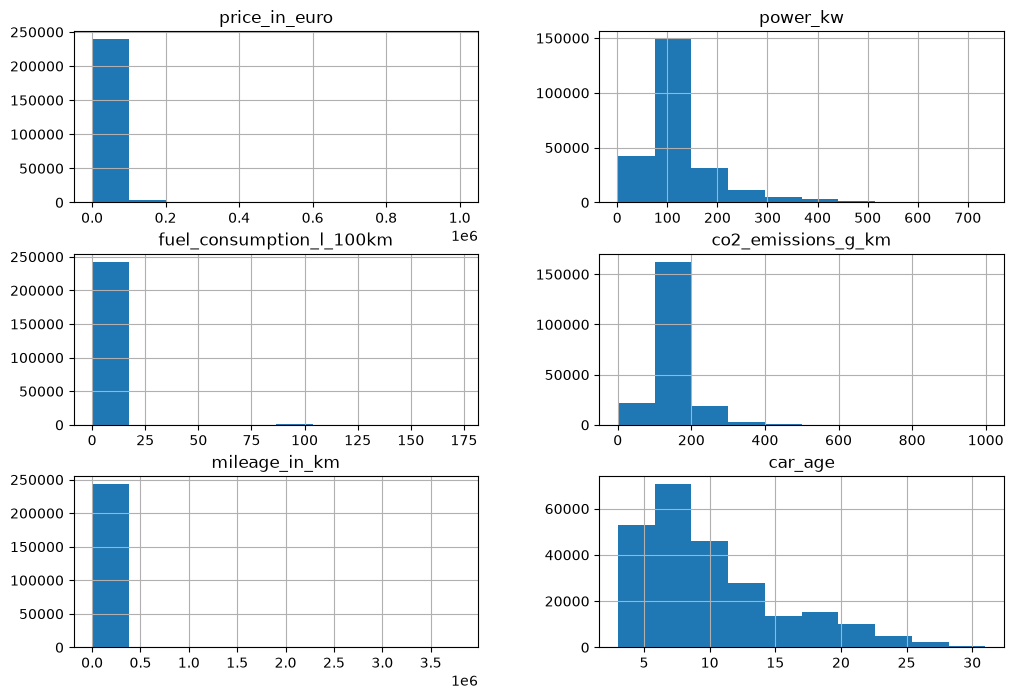

In [5]:
numeric_cols = [
    'price_in_euro',
    'power_kw',
    'fuel_consumption_l_100km',
    'co2_emissions_g_km',
    'mileage_in_km',
    'car_age'
]

df[numeric_cols].hist(figsize=(12, 8))

<Axes: >

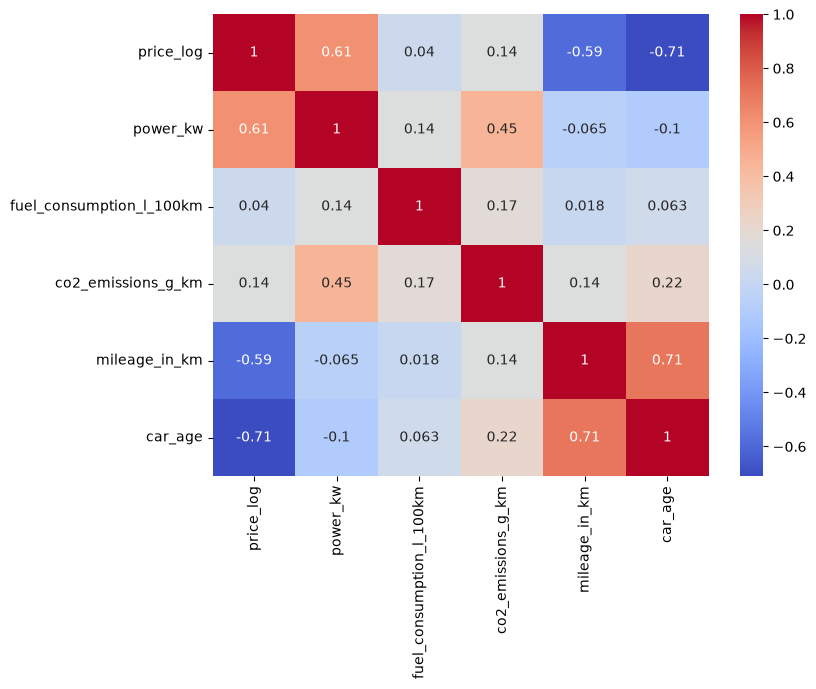

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['price_log',
        'power_kw',
        'fuel_consumption_l_100km',
        'co2_emissions_g_km',
        'mileage_in_km',
        'car_age']].corr(),
    annot=True,
    cmap='coolwarm'
)

In [ ]:
categorical_cols = ['brand', 'model', 'color', 'transmission_type', 'fuel_type']

for col in categorical_cols:
    print(f'{col}:')
    print(f'Anzahl der eindeutigen Werte: {df[col].nunique()}')
    print(df[col].value_counts().head(10))
    print('-' * 50)

brand:
Количество уникальных значений: 47
brand
volkswagen       32901
mercedes-benz    26897
audi             20797
opel             19748
bmw              19664
ford             18215
skoda            13469
seat             11460
renault           8209
toyota            7543
Name: count, dtype: int64
--------------------------------------------------
model:
Количество уникальных значений: 1312
model
Volkswagen Golf    7519
Opel Astra         4220
Opel Corsa         4126
SEAT Leon          4014
Ford Focus         3802
Skoda Octavia      3689
Audi A3            3481
Audi A4            3359
Volkswagen Polo    3107
Audi A6            2859
Name: count, dtype: int64
--------------------------------------------------
color:
Количество уникальных значений: 14
color
black     57507
grey      45573
white     39312
silver    33451
blue      31005
red       20489
brown      4299
green      3387
orange     3158
beige      2260
Name: count, dtype: int64
--------------------------------------------

In [8]:
df['mileage_in_km'] = df['mileage_in_km'].fillna(df['mileage_in_km'].median())

In [9]:
df['color'] = df['color'].fillna('Unknown')

In [10]:
df.shape
df.head()
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 243769 entries, 0 to 243768
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     243769 non-null  str    
 1   model                     243769 non-null  str    
 2   color                     243769 non-null  str    
 3   price_in_euro             243769 non-null  int64  
 4   power_kw                  243769 non-null  float64
 5   transmission_type         243769 non-null  str    
 6   fuel_type                 243769 non-null  str    
 7   fuel_consumption_l_100km  243769 non-null  float64
 8   co2_emissions_g_km        207370 non-null  float64
 9   mileage_in_km             243769 non-null  float64
 10  price_log                 243769 non-null  float64
 11  car_age                   243769 non-null  int64  
 12  has_fuel_consumption      243769 non-null  int64  
 13  has_co2                   243769 non-null  int64  
 14 

In [11]:
features = [
    'brand',
    'model',
    'color',
    'power_kw',
    'transmission_type',
    'fuel_type',
    'fuel_consumption_l_100km',
    'co2_emissions_g_km',
    'mileage_in_km',
    'car_age',
    'has_fuel_consumption',
    'has_co2',
    'is_electric'
]

In [12]:
target = 'price_log'

In [13]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
cat_features = [
    'brand',
    'model',
    'color',
    'transmission_type',
    'fuel_type'
]

In [15]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

In [16]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 0.8216791	test: 0.8225787	best: 0.8225787 (0)	total: 529ms	remaining: 8m 48s
100:	learn: 0.2612456	test: 0.2613557	best: 0.2613557 (100)	total: 30.4s	remaining: 4m 30s
200:	learn: 0.2468680	test: 0.2478752	best: 0.2478752 (200)	total: 59.8s	remaining: 3m 57s
300:	learn: 0.2397409	test: 0.2418403	best: 0.2418403 (300)	total: 1m 30s	remaining: 3m 29s
400:	learn: 0.2346252	test: 0.2379855	best: 0.2379855 (400)	total: 2m	remaining: 3m
500:	learn: 0.2309708	test: 0.2355392	best: 0.2355392 (500)	total: 2m 30s	remaining: 2m 30s
600:	learn: 0.2281011	test: 0.2336949	best: 0.2336949 (600)	total: 3m 1s	remaining: 2m
700:	learn: 0.2256117	test: 0.2322462	best: 0.2322462 (700)	total: 3m 30s	remaining: 1m 29s
800:	learn: 0.2234490	test: 0.2311151	best: 0.2311151 (800)	total: 3m 59s	remaining: 59.4s
900:	learn: 0.2216626	test: 0.2302065	best: 0.2302065 (900)	total: 4m 28s	remaining: 29.5s
999:	learn: 0.2201992	test: 0.2295422	best: 0.2295397 (998)	total: 4m 58s	remaining: 0us

bestTest = 0

In [18]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))
print(rmse)

0.2295397480584056


In [19]:
import numpy as np

pred_price = np.exp(pred)
y_test_price = np.exp(y_test)

In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_price, pred_price))
print(rmse)

11951.346453326802


In [21]:
df['price_in_euro'].describe()

count     243769.000000
mean       25943.669531
std        32924.387841
min          120.000000
25%        11900.000000
50%        19599.000000
75%        29900.000000
max      1000000.000000
Name: price_in_euro, dtype: float64

In [22]:
df['price_in_euro'].quantile([0.9, 0.95, 0.99])

0.90     45890.0
0.95     62900.0
0.99    149999.0
Name: price_in_euro, dtype: float64

In [23]:
errors = abs(y_test_price - pred_price)

errors.describe()

count     48754.000000
mean       3598.390710
std       11396.882491
min           0.084623
25%         662.466542
50%        1538.942180
75%        3295.846189
max      741235.742988
Name: price_log, dtype: float64

In [24]:
df['price_log'].head()

0     7.170888
1    10.122663
2     8.682877
3     8.497195
4     9.795401
Name: price_log, dtype: float64

In [29]:
df['co2_emissions_g_km'].isna().sum()

36399

In [30]:
df['co2_emissions_g_km'] = df['co2_emissions_g_km'].fillna(
    df.groupby('model')['co2_emissions_g_km'].transform('median')
)

In [31]:
df['co2_emissions_g_km'].isna().sum()

113

In [32]:
df['co2_emissions_g_km'] = df['co2_emissions_g_km'].fillna(
    df.groupby('fuel_type')['co2_emissions_g_km'].transform('median')
)

In [33]:
df['co2_emissions_g_km'] = df['co2_emissions_g_km'].fillna(
    df['co2_emissions_g_km'].median()
)

In [34]:
df['co2_emissions_g_km'].isna().sum()

0

In [35]:
model_freq = df['model'].value_counts()

df['model_frequency'] = df['model'].map(model_freq)

In [36]:
df[['model', 'model_frequency']].head()

,model,model_frequency
0,Alfa Romeo GTV,17
1,Alfa Romeo 164,3
2,Alfa Romeo Spider,77
3,Alfa Romeo Spider,77
4,Alfa Romeo 164,3


In [37]:
df = df.drop(columns='model')

In [38]:
df['color'] = df['color'].fillna('Unknown')

In [39]:
categorical_cols = [
    'brand',
    'fuel_type',
    'color',
    'transmission_type'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [40]:
print(df_encoded.shape)

df_encoded.head()

(243769, 78)


,price_in_euro,power_kw,fuel_consumption_l_100km,co2_emissions_g_km,mileage_in_km,price_log,car_age,has_fuel_consumption,has_co2,is_electric,...,color_grey,color_orange,color_red,color_silver,color_violet,color_white,color_yellow,transmission_type_Manual,transmission_type_Semi-automatic,transmission_type_Unknown
0,1300,148.0,10.0,260.0,160500.0,7.170888,31,1,1,0,...,0,0,1,0,0,0,0,1,0,0
1,24900,191.0,6.0,320.0,190000.0,10.122663,31,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,5900,110.0,6.0,220.0,129000.0,8.682877,31,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4900,110.0,9.0,225.0,189500.0,8.497195,31,1,1,0,...,0,0,0,0,0,0,0,1,0,0
4,17950,132.0,7.0,320.0,96127.0,9.795401,30,1,0,0,...,0,0,1,0,0,0,0,1,0,0


In [41]:
print(df_encoded.columns.tolist())

['price_in_euro', 'power_kw', 'fuel_consumption_l_100km', 'co2_emissions_g_km', 'mileage_in_km', 'price_log', 'car_age', 'has_fuel_consumption', 'has_co2', 'is_electric', 'model_frequency', 'brand_aston-martin', 'brand_audi', 'brand_bentley', 'brand_bmw', 'brand_cadillac', 'brand_chevrolet', 'brand_chrysler', 'brand_citroen', 'brand_dacia', 'brand_daewoo', 'brand_daihatsu', 'brand_dodge', 'brand_ferrari', 'brand_fiat', 'brand_ford', 'brand_honda', 'brand_hyundai', 'brand_infiniti', 'brand_isuzu', 'brand_jaguar', 'brand_jeep', 'brand_kia', 'brand_lada', 'brand_lamborghini', 'brand_lancia', 'brand_land-rover', 'brand_maserati', 'brand_mazda', 'brand_mercedes-benz', 'brand_mini', 'brand_mitsubishi', 'brand_nissan', 'brand_opel', 'brand_peugeot', 'brand_porsche', 'brand_proton', 'brand_renault', 'brand_rover', 'brand_saab', 'brand_seat', 'brand_skoda', 'brand_smart', 'brand_ssangyong', 'brand_toyota', 'brand_volkswagen', 'brand_volvo', 'fuel_type_Electric', 'fuel_type_Hybrid', 'fuel_type_O

In [42]:
df_encoded.to_csv(
    'data/cars_ml_onehot.csv',
    index=False
)

In [14]:
df = pd.read_csv(
    "../data/cars_ml_onehot.csv"
)

print(df.columns.tolist())

['price_in_euro', 'power_kw', 'fuel_consumption_l_100km', 'co2_emissions_g_km', 'mileage_in_km', 'price_log', 'car_age', 'has_fuel_consumption', 'has_co2', 'is_electric', 'model_frequency', 'brand_aston-martin', 'brand_audi', 'brand_bentley', 'brand_bmw', 'brand_cadillac', 'brand_chevrolet', 'brand_chrysler', 'brand_citroen', 'brand_dacia', 'brand_daewoo', 'brand_daihatsu', 'brand_dodge', 'brand_ferrari', 'brand_fiat', 'brand_ford', 'brand_honda', 'brand_hyundai', 'brand_infiniti', 'brand_isuzu', 'brand_jaguar', 'brand_jeep', 'brand_kia', 'brand_lada', 'brand_lamborghini', 'brand_lancia', 'brand_land-rover', 'brand_maserati', 'brand_mazda', 'brand_mercedes-benz', 'brand_mini', 'brand_mitsubishi', 'brand_nissan', 'brand_opel', 'brand_peugeot', 'brand_porsche', 'brand_proton', 'brand_renault', 'brand_rover', 'brand_saab', 'brand_seat', 'brand_skoda', 'brand_smart', 'brand_ssangyong', 'brand_toyota', 'brand_volkswagen', 'brand_volvo', 'fuel_type_Electric', 'fuel_type_Hybrid', 'fuel_type_O